## State Sector Classification (via LQs)

| Sector | Number of States | States |
|------|------|------|
Construction | 4 | Arizona, Louisiana, Texas, Utah
Energy | 14 | Alaska, Arkansas, Idaho, Mississippi, Montana, Nebraska, New Mexico, North Dakota, Oklahoma, Oregon, South Dakota, Vermont, West Virginia, Wyoming
Finance | 8 | Connecticut, Delaware, Minnesota, New Jersey, New York, North Carolina, Pennsylvania, Rhode Island
Manufacturing | 13 | Alabama, Illinois, Indiana, Iowa, Kansas, Kentucky, Michigan, Missouri, New Hampshire, Ohio, South Carolina, Tennessee, Wisconsin
Tech | 7 | California, Colorado, Georgia, Maryland, Massachusetts, Virginia, Washington
Tourism | 4 | Florida, Hawaii, Maine, Nevada




---

## 1. Location Quotient (LQ) used to Classify States by Industry

We measure how “specialized” a state is in an industry using **Location Quotients (LQ)**
In particiular, LQ measures whether a sector is **more concentrated in a state than in the national economy**.

**Industry share (important detail):**

We use employee compensation data by industry. This choice is explained below.


The industry share is:


$$\text{Industry share}_{s,i} =
\frac{\text{Compensation in industry } i \text{ in state } s}{\text{Total compensation in state } s}$$

So LQ compares:

- the **fraction of total wages in a state** coming from an industry  
- to the **same fraction at the national level**

We define:

- $i$ = industry  
- $j$ = state index used when summing across all states  
- $s$ = state index   
- $k$ = industry index used when summing across all industries  
- $C_{s,i}$ = compensation in industry $i$ in state $i$


### Step 1. State industry share

First compute the share of industry $i$ within the economy of state $s$.

$$
\text{StateShare}_{s,i} =
\frac{C_{s,i}}{\sum_{k} C_{s,k}}
$$

Explanation:

- $C_{s,i}$ is compensation in industry $i$ in state $s$  
- $\sum_k C_{s,k}$ is the **sum of compensation across all industries $k$ within state $s$**

Thus the denominator represents **total compensation across all industries in that state**.

This measures the **importance of industry $i$ within the state's economy**.



### Step 2. National sector share

Next compute the share of industry $i$ in the national economy.

$$
\text{NationalShare}_{i} =
\frac{\sum_{j} C_{j,i}}
{\sum_{j}\sum_{k} C_{j,k}}
$$

Explanation:

- $\sum_j C_{j,i}$ is **total U.S. compensation in industry $i$ across all states**
- $\sum_j \sum_k C_{j,k}$ is **total compensation across all industries and all states**

Thus the denominator represents **total national compensation across the entire economy**.

This measures the **importance of sector $i$ in the national economy**.


### Step 3. Location Quotient

The Location Quotient compares the state's industry share to the national industry share.

$$
LQ_{s,i} =
\dfrac{\text{StateShare}_{s,i}}
{\text{NationalShare}_{i}}
$$

Substituting the expressions above:

$$
LQ_{s,i} =
\dfrac{\left(\dfrac{C_{s,i}}{\sum_k C_{s,k}}\right)}
{\left(\dfrac{\sum_j C_{j,i}}{\sum_j \sum_k C_{j,k}}\right)}
$$


### Interpretation

- $LQ_{s,i} > 1$ $\rightarrow$ industry $s$ is **more concentrated in state $s$ than nationally**  
- $LQ_{s,i} = 1$ $\rightarrow$ industry has the **same concentration as the national average**  
- $LQ_{s,i} < 1$ $\rightarrow$ industry is **less concentrated than average**

For each state $s$, the **dominant industry** is defined as the industry $i$ with the **largest $LQ_{s,i}$**.


**Literature/Sources for LQ:**
* https://en.wikipedia.org/wiki/Economic_base_analysis
* https://www.researchgate.net/publication/343440887_Location_Quotient_Analysis_LQ_in_Determining_the_Excellent_Commodity
* https://www.federalreserve.gov/econres/ifdp/files/ifdp1329.pdf
* https://www.incontext.indiana.edu/2006/march/1.asp 
* https://digitalcommons.unl.edu/cgi/viewcontent.cgi?article=2262&context=agecon_cornhusker
* https://www.bls.gov/cew/about-data/location-quotients-explained.htm

LQ = share of industry locally / share nationally

Variables used in above sources are employment, GDP, earnings/income etc. 

**Important Remark.** Location quotients are typically computed using employment, but the method applies to any measure of industry size, including income or output. We use compensation of employees because it directly measures labor income, which is more relevant for housing demand than employment counts or GDP. In particular, total employee compensation is a better captures purchasing power of potential homebuyers. 

---

## 2. Data choice: compensation of employees

We use **compensation of employees (wages + salaries)** from the BEA.

**Data source:**

- BEA SAINC6N  
  https://apps.bea.gov/iTable/


**Why this choice?**

• Measures **income actually earned by workers**  
• Housing markets depend on **income and employment**  
• Reflects money received by residents of the state  

GDP includes:

- corporate profits  
- capital income  

These may not go to people living in the state, and therefore may not accurately reflect household income or local economic conditions relevant for housing markets.

Since we are studying housing (listings, sales), compensation is a measure of **housing demand**.

---

## 3. Tradable vs non-tradable industries

We adopt the tradable vs non-tradable framework of industries from regional economics. 

Non-tradable industries are present everywhere and primarily reflect local demand. In particular, 
- tradable industries determine **regional differences**  
- non-tradable industries mainly **follow population**

**Sources:**

- Moretti (2012), *The New Geography of Jobs*
  Moretti, E. (2012). The New Geography of Jobs. New York: Houghton Mifflin Harcourt.  
- Jensen & Kletzer (2005), *Tradable Services*
  https://www.piie.com/publications/working-papers/tradable-services-understanding-scope-and-impact-services-outsourcing 
   
  This paper shows that many industries differ in their ability to be traded, and that **tradable activities tend to be higher skill and more geographically concentrated**
 


This framework distinguishes:

### Tradable industries

- sell goods/services **outside the region**  
- vary across states  
- drive **regional specialization**

Examples:

- manufacturing  
- tech  
- finance  
- energy  
- tourism  


### Non-tradable industries

- serve **local demand**  
- exist in nearly every state  

Examples:

- retail  
- healthcare  
- education  
- real estate  

### Government

Government is treated as **non-tradable**:

- provides local services  
- scales with population and policy  
- does not reflect market specialization  

Slope (log-log): 1.1759
Correlation (log-log): 0.9704


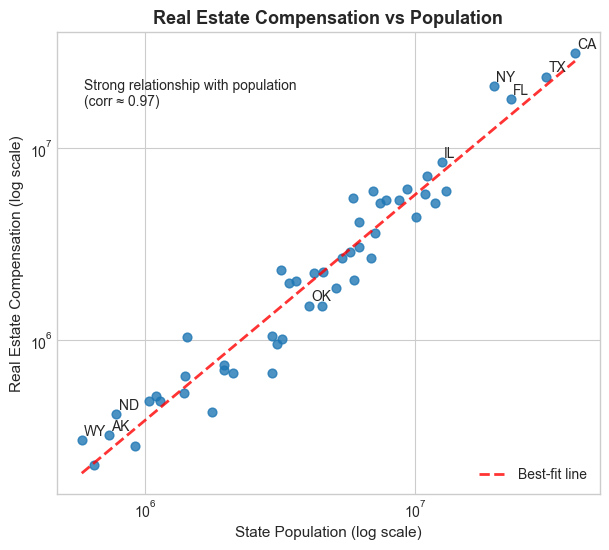

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your cleaned dataset
df = pd.read_csv("cleaned_state_industry_data.csv")

# Identify columns
state_col = [c for c in df.columns if "state" in c.lower()][0]
industry_col = [c for c in df.columns if "industry" in c.lower()][0]
value_col = [c for c in df.columns if "2023" in c.lower() or "comp" in c.lower()][0]

# State population data
state_population = {
"Alabama":5108468,"Alaska":733406,"Arizona":7431344,"Arkansas":3067732,"California":38965193,
"Colorado":5877610,"Connecticut":3617176,"Delaware":1031985,"Florida":22610726,"Georgia":11029227,
"Hawaii":1435138,"Idaho":1964726,"Illinois":12549689,"Indiana":6862199,"Iowa":3207004,
"Kansas":2940546,"Kentucky":4526154,"Louisiana":4573749,"Maine":1395722,"Maryland":6180253,
"Massachusetts":7001399,"Michigan":10037261,"Minnesota":5737915,"Mississippi":2939690,"Missouri":6196156,
"Montana":1132812,"Nebraska":1967923,"Nevada":3194176,"New Hampshire":1402954,"New Jersey":9290841,
"New Mexico":2113344,"New York":19571216,"North Carolina":10835491,"North Dakota":783926,"Ohio":11785935,
"Oklahoma":4053824,"Oregon":4233358,"Pennsylvania":12961683,"Rhode Island":1095962,"South Carolina":5373555,
"South Dakota":919318,"Tennessee":7126489,"Texas":30503301,"Utah":3417734,"Vermont":647156,
"Virginia":8715698,"Washington":7812880,"West Virginia":1770071,"Wisconsin":5910955,"Wyoming":584057
}

state_abbrev = {
"Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
"Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
"Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
"Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
"Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO",
"Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ",
"New Mexico":"NM","New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH",
"Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
"South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
"Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

# Real estate compensation per state
real_estate = df[df[industry_col].str.contains("Real estate and rental and leasing", case=False, na=False)]
real_estate_by_state = real_estate.groupby(state_col)[value_col].sum()

# Combine into dataframe
plot_df = pd.DataFrame({
    "population": pd.Series(state_population),
    "real_estate_comp": real_estate_by_state
}).dropna()

# Plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(7,6))
plt.scatter(plot_df["population"], plot_df["real_estate_comp"], s = 40, alpha = 0.8)

# Highlight selected states
highlight_states = [ "California",
    "Texas",
    "New York",
    "Florida",
    "Illinois",
    "North Dakota",
    "Wyoming",
    "Alaska",
    "Oklahoma"]

for state in highlight_states:
    if state in plot_df.index:
        x_val = plot_df.loc[state, "population"]
        y_val = plot_df.loc[state, "real_estate_comp"]
        plt.text(x_val * 1.02, y_val * 1.02, state_abbrev[state], fontsize=10, ha='left', va='bottom')

# --- Log scales ---
plt.xscale("log")
plt.yscale("log")

# --- Best-fit curve (log-log regression) ---
x = plot_df["population"]
y = plot_df["real_estate_comp"]

log_x = np.log(x)
log_y = np.log(y)

b, a = np.polyfit(log_x, log_y, 1)
corr = np.corrcoef(log_x, log_y)[0,1]

print(f"Slope (log-log): {b:.4f}")
print(f"Correlation (log-log): {corr:.4f}")

x_line = np.linspace(x.min(), x.max(), 100)
y_line = np.exp(a) * x_line**b

plt.plot(x_line, y_line, linestyle='--', color = 'red', linewidth=2, label='Best-fit line', alpha = 0.8)

# --- Annotation ---
plt.text(
    0.05, 0.9,
    "Strong relationship with population\n(corr ≈ 0.97)",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top'
)

# Labels and title
plt.xlabel("State Population (log scale)", fontsize = 11)
plt.ylabel("Real Estate Compensation (log scale)", fontsize = 11)
plt.title("Real Estate Compensation vs Population", fontsize = 13, weight = 'bold')
plt.legend(loc='lower right')



plt.show()

Slope (log-log): 0.4062
Correlation (log-log): 0.2757


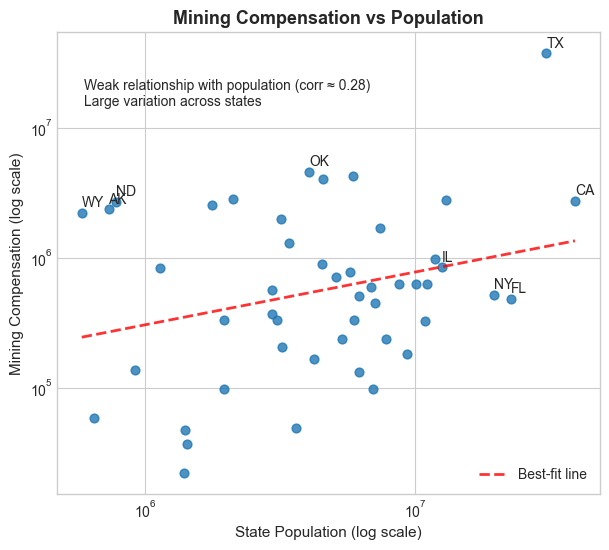

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your cleaned dataset
df = pd.read_csv("cleaned_state_industry_data.csv")

# Identify columns
state_col = [c for c in df.columns if "state" in c.lower()][0]
industry_col = [c for c in df.columns if "industry" in c.lower()][0]
value_col = [c for c in df.columns if "2023" in c.lower() or "comp" in c.lower()][0]

# State population data
state_population = {
"Alabama":5108468,"Alaska":733406,"Arizona":7431344,"Arkansas":3067732,"California":38965193,
"Colorado":5877610,"Connecticut":3617176,"Delaware":1031985,"Florida":22610726,"Georgia":11029227,
"Hawaii":1435138,"Idaho":1964726,"Illinois":12549689,"Indiana":6862199,"Iowa":3207004,
"Kansas":2940546,"Kentucky":4526154,"Louisiana":4573749,"Maine":1395722,"Maryland":6180253,
"Massachusetts":7001399,"Michigan":10037261,"Minnesota":5737915,"Mississippi":2939690,"Missouri":6196156,
"Montana":1132812,"Nebraska":1967923,"Nevada":3194176,"New Hampshire":1402954,"New Jersey":9290841,
"New Mexico":2113344,"New York":19571216,"North Carolina":10835491,"North Dakota":783926,"Ohio":11785935,
"Oklahoma":4053824,"Oregon":4233358,"Pennsylvania":12961683,"Rhode Island":1095962,"South Carolina":5373555,
"South Dakota":919318,"Tennessee":7126489,"Texas":30503301,"Utah":3417734,"Vermont":647156,
"Virginia":8715698,"Washington":7812880,"West Virginia":1770071,"Wisconsin":5910955,"Wyoming":584057
}

state_abbrev = {
"Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
"Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
"Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
"Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
"Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO",
"Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ",
"New Mexico":"NM","New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH",
"Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC",
"South Dakota":"SD","Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
"Virginia":"VA","Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

# Mining compensation per state
mining = df[df[industry_col].str.contains("mining", case=False, na=False)]
mining_by_state = mining.groupby(state_col)[value_col].sum()

# Combine into dataframe
plot_df = pd.DataFrame({
    "population": pd.Series(state_population),
    "mining_comp": mining_by_state
}).dropna()

# Plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(7,6))
plt.scatter(plot_df["population"], plot_df["mining_comp"], s = 40, alpha = 0.8)

# Highlight states
highlight_states = [
    "California", "Texas", "New York", "Florida", "Illinois",
    "North Dakota", "Wyoming", "Alaska", "Oklahoma"
]

for state in highlight_states:
    if state in plot_df.index:
        x = plot_df.loc[state, "population"]
        y = plot_df.loc[state, "mining_comp"]
        plt.text(x * 1.00, y * 1.05, state_abbrev[state], fontsize=10, ha='left', va='bottom')

# Log scales
plt.xscale("log")
plt.yscale("log")



# --- Best-fit curve (log-log regression, safe) ---
x = plot_df["population"]
y = plot_df["mining_comp"]

mask = (x > 0) & (y > 0)

log_x = np.log(x[mask])
log_y = np.log(y[mask])

b, a = np.polyfit(log_x, log_y, 1)
corr = np.corrcoef(log_x, log_y)[0,1]

print(f"Slope (log-log): {b:.4f}")
print(f"Correlation (log-log): {corr:.4f}")


x_line = np.linspace(x.min(), x.max(), 100)
y_line = np.exp(a) * x_line**b

plt.plot(x_line, y_line, linestyle='--', color = 'red', linewidth=2, label='Best-fit line', alpha = 0.8)


# --- Annotation ---
plt.text(
    0.05, 0.9,
    "Weak relationship with population (corr ≈ 0.28) \nLarge variation across states",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top'
)

# Labels
plt.xlabel("State Population (log scale)", fontsize = 11)
plt.ylabel("Mining Compensation (log scale)", fontsize = 11)
plt.title("Mining Compensation vs Population", fontsize = 13, weight = 'bold')
plt.legend(loc='lower right')



plt.show()

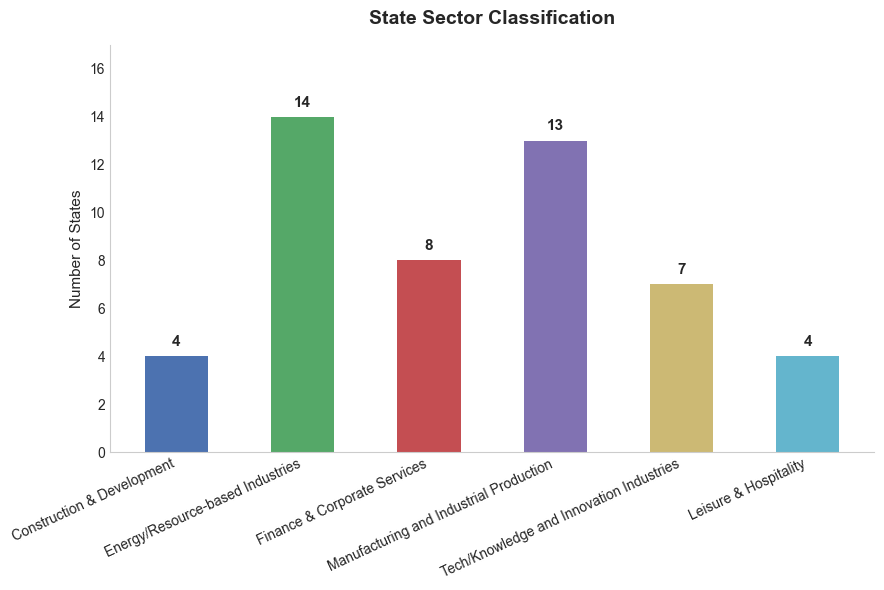

In [65]:
import matplotlib.pyplot as plt

# Data
sectors = [
    "Construction & Development",
    "Energy/Resource-based Industries",
    "Finance & Corporate Services",
    "Manufacturing and Industrial Production",
    "Tech/Knowledge and Innovation Industries",
    "Leisure & Hospitality"
]

counts = [4, 14, 8, 13, 7, 4]

colors = [
    "#4C72B0",  # blue
    "#55A868",  # green
    "#C44E52",  # red
    "#8172B2",  # purple
    "#CCB974",  # gold
    "#64B5CD"   # light blue
]

# Create figure
fig, ax = plt.subplots(figsize=(9,6))

# Thinner bars
bars = ax.bar(sectors, counts, color = colors, width=0.5)

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height}",
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold'
    )

# Title and labels
ax.set_title("State Sector Classification", fontsize=14, weight='bold', pad=15)
ax.set_ylabel("Number of States", fontsize=11)

# Remove gridlines completely
ax.grid(False)

# Remove top/right spines (modern look)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lighten left/bottom spines
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Rotate x labels slightly
plt.xticks(rotation=25, ha='right')

# Add breathing room
ax.set_ylim(0, max(counts) + 3)

plt.tight_layout()
plt.show()

## EDA on other industries (or sectors) vs. population

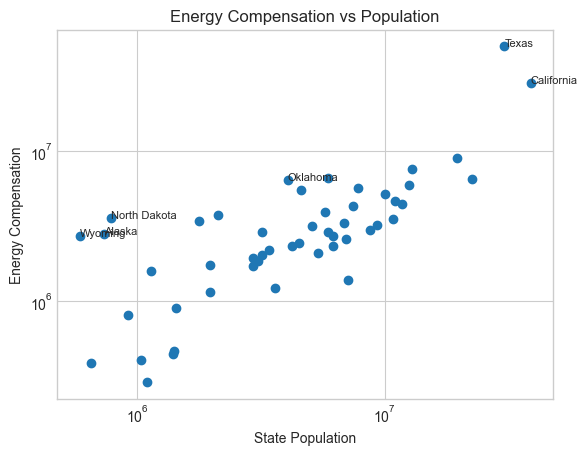

In [ ]:
#Aggregate mining, utilities, and farming compensation under sector label "Energy/Resource-based industries" and compare it with population.

import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("cleaned_state_industry_data.csv")

# Identify columns
state_col = [c for c in df.columns if "state" in c.lower()][0]
industry_col = [c for c in df.columns if "industry" in c.lower()][0]
value_col = [c for c in df.columns if "2023" in c.lower() or "comp" in c.lower()][0]

# State population data
state_population = {
"Alabama":5108468,"Alaska":733406,"Arizona":7431344,"Arkansas":3067732,"California":38965193,
"Colorado":5877610,"Connecticut":3617176,"Delaware":1031985,"Florida":22610726,"Georgia":11029227,
"Hawaii":1435138,"Idaho":1964726,"Illinois":12549689,"Indiana":6862199,"Iowa":3207004,
"Kansas":2940546,"Kentucky":4526154,"Louisiana":4573749,"Maine":1395722,"Maryland":6180253,
"Massachusetts":7001399,"Michigan":10037261,"Minnesota":5737915,"Mississippi":2939690,"Missouri":6196156,
"Montana":1132812,"Nebraska":1967923,"Nevada":3194176,"New Hampshire":1402954,"New Jersey":9290841,
"New Mexico":2113344,"New York":19571216,"North Carolina":10835491,"North Dakota":783926,"Ohio":11785935,
"Oklahoma":4053824,"Oregon":4233358,"Pennsylvania":12961683,"Rhode Island":1095962,"South Carolina":5373555,
"South Dakota":919318,"Tennessee":7126489,"Texas":30503301,"Utah":3417734,"Vermont":647156,
"Virginia":8715698,"Washington":7812880,"West Virginia":1770071,"Wisconsin":5910955,"Wyoming":584057
}

# --- Define energy industries ---
energy_industries = ["farm", "mining", "utilities"]

# Filter energy-related rows
energy_df = df[df[industry_col].str.contains('|'.join(energy_industries), case=False, na=False)]

# Aggregate energy compensation by state
energy_by_state = energy_df.groupby(state_col)[value_col].sum()

# Build dataframe
plot_df = pd.DataFrame({
    "population": pd.Series(state_population),
    "energy_comp": energy_by_state
}).dropna()

# Plot
plt.figure()
plt.scatter(plot_df["population"], plot_df["energy_comp"])

plt.xlabel("State Population")
plt.ylabel("Energy Compensation")
plt.title("Energy Compensation vs Population")

highlight_states = ["Texas", "North Dakota", "Wyoming", "Alaska", "Oklahoma", "California"]

for state in highlight_states:
    if state in plot_df.index:
        x = plot_df.loc[state, "population"]
        y = plot_df.loc[state, "energy_comp"]
        plt.text(x, y, state, fontsize=8)

plt.xscale("log")
plt.yscale("log")

plt.show()

In [68]:
corr_energy = plot_df["population"].corr(plot_df["energy_comp"])
print("Correlation (Energy Levels vs Population):", corr_energy)

Correlation (Energy Levels vs Population): 0.8015150118795932


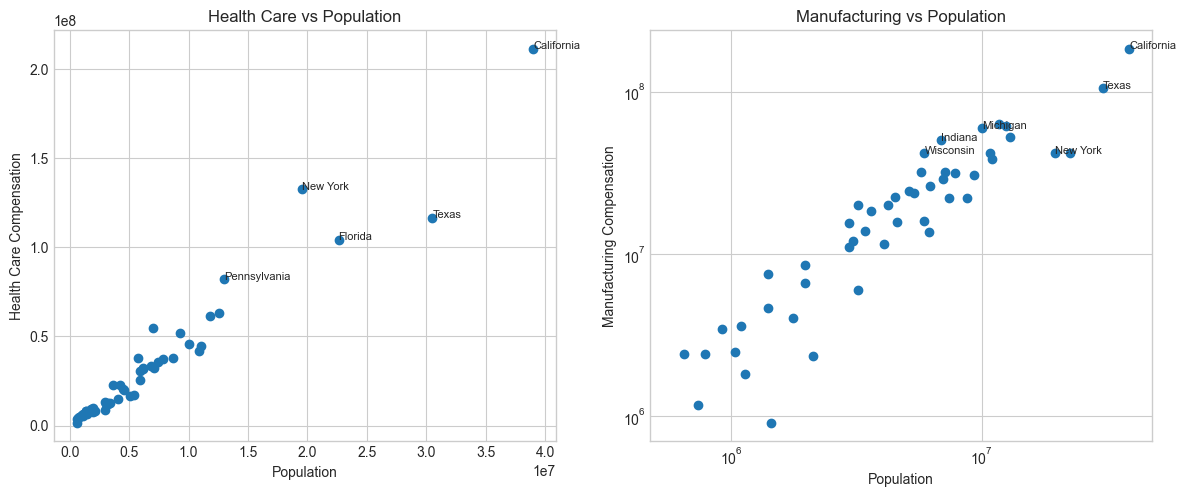

Correlation (Health vs Population): 0.970402690745425
Correlation (Manufacturing vs Population): 0.9209884352257942


In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("cleaned_state_industry_data.csv")

# Identify columns
state_col = [c for c in df.columns if "state" in c.lower()][0]
industry_col = [c for c in df.columns if "industry" in c.lower()][0]
value_col = [c for c in df.columns if "2023" in c.lower() or "comp" in c.lower()][0]

# Population data
state_population = {
"Alabama":5108468,"Alaska":733406,"Arizona":7431344,"Arkansas":3067732,"California":38965193,
"Colorado":5877610,"Connecticut":3617176,"Delaware":1031985,"Florida":22610726,"Georgia":11029227,
"Hawaii":1435138,"Idaho":1964726,"Illinois":12549689,"Indiana":6862199,"Iowa":3207004,
"Kansas":2940546,"Kentucky":4526154,"Louisiana":4573749,"Maine":1395722,"Maryland":6180253,
"Massachusetts":7001399,"Michigan":10037261,"Minnesota":5737915,"Mississippi":2939690,"Missouri":6196156,
"Montana":1132812,"Nebraska":1967923,"Nevada":3194176,"New Hampshire":1402954,"New Jersey":9290841,
"New Mexico":2113344,"New York":19571216,"North Carolina":10835491,"North Dakota":783926,"Ohio":11785935,
"Oklahoma":4053824,"Oregon":4233358,"Pennsylvania":12961683,"Rhode Island":1095962,"South Carolina":5373555,
"South Dakota":919318,"Tennessee":7126489,"Texas":30503301,"Utah":3417734,"Vermont":647156,
"Virginia":8715698,"Washington":7812880,"West Virginia":1770071,"Wisconsin":5910955,"Wyoming":584057
}

# --- Healthcare ---
health_df = df[df[industry_col].str.contains("health care|healthcare", case=False, na=False)]
health_by_state = health_df.groupby(state_col)[value_col].sum()

# --- Manufacturing ---
manu_df = df[df[industry_col].str.contains("manufacturing", case=False, na=False)]
manu_by_state = manu_df.groupby(state_col)[value_col].sum()

# Build dataframes
health_plot = pd.DataFrame({
    "population": pd.Series(state_population),
    "health": health_by_state
}).dropna()

manu_plot = pd.DataFrame({
    "population": pd.Series(state_population),
    "manufacturing": manu_by_state
}).dropna()

# --- Correlations ---
corr_health = health_plot["population"].corr(health_plot["health"])
corr_manu = manu_plot["population"].corr(manu_plot["manufacturing"])

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Health care plot
axes[0].scatter(health_plot["population"], health_plot["health"])
axes[0].set_title("Health Care vs Population")
axes[0].set_xlabel("Population")
axes[0].set_ylabel("Health Care Compensation")

# Label key states (population-driven)
for state in ["California","Texas","Florida","New York","Pennsylvania"]:
    if state in health_plot.index:
        x = health_plot.loc[state,"population"]
        y = health_plot.loc[state,"health"]
        axes[0].text(x,y,state,fontsize=8)

# Manufacturing plot
axes[1].scatter(manu_plot["population"], manu_plot["manufacturing"])
axes[1].set_title("Manufacturing vs Population")
axes[1].set_xlabel("Population")
axes[1].set_ylabel("Manufacturing Compensation")

# Label distinguishing states
for state in ["Michigan","Indiana","Wisconsin","California","Texas","New York"]:
    if state in manu_plot.index:
        x = manu_plot.loc[state,"population"]
        y = manu_plot.loc[state,"manufacturing"]
        axes[1].text(x,y,state,fontsize=8)

plt.tight_layout()
plt.xscale("log")
plt.yscale("log")
plt.show()

# Print correlations
print("Correlation (Health vs Population):", corr_health)
print("Correlation (Manufacturing vs Population):", corr_manu)

In [71]:
import pandas as pd

# load data
df = pd.read_csv("cleaned_state_industry_data.csv")

# pivot to wide format: rows = states, columns = industries
wide = df.pivot(index="state", columns="industry", values="compensation")

# convert to shares within each state
shares = wide.div(wide.sum(axis=1), axis=0)

# compute summary statistics across states for each industry
summary_table = pd.DataFrame({
    "min": shares.min(),
    "max": shares.max(),
    "mean": shares.mean(),
    "std_dev": shares.std()
})

# optional: sort by mean or std deviation
summary_table = summary_table.sort_values(by="mean", ascending=False)

# display
print(summary_table)

# save if needed
summary_table.to_csv("industry_share_summary_stats.csv")

                                                         min       max  \
industry                                                                 
  Government and government enterprises             0.121175  0.338742   
    Health care and social assistance               0.081713  0.186689   
    Manufacturing                                   0.000000  0.212033   
    Professional, scientific, and technical ser...  0.044269  0.182634   
    Finance and insurance                           0.021518  0.165560   
    Retail trade                                    0.046681  0.087516   
    Construction                                    0.036861  0.089630   
    Wholesale trade                                 0.018135  0.074318   
    Administrative and support and waste manage...  0.024004  0.062095   
    Accommodation and food services                 0.029787  0.136754   
    Transportation and warehousing                  0.019560  0.075165   
    Management of companies and enterp

### Industry Shares Across All States

| Industry                                              |   min |   max |   mean |   std_dev |
|:------------------------------------------------------|------:|------:|-------:|----------:|
| Government and government enterprises                | 0.1212 | 0.2970 | 0.2023 | 0.0487 |
| Health care and social assistance                    | 0.0817 | 0.1676 | 0.1276 | 0.0223 |
| Manufacturing                                       | 0.0000 | 0.2315 | 0.1075 | 0.0442 |
| Professional, scientific, and technical services     | 0.0443 | 0.1522 | 0.0877 | 0.0328 |
| Finance and insurance                               | 0.0215 | 0.1820 | 0.0716 | 0.0294 |
| Retail trade                                        | 0.0467 | 0.0958 | 0.0705 | 0.0097 |
| Construction                                        | 0.0369 | 0.0954 | 0.0634 | 0.0122 |
| Wholesale trade                                     | 0.0181 | 0.0712 | 0.0475 | 0.0119 |
| Administrative and support services                 | 0.0240 | 0.0623 | 0.0453 | 0.0084 |
| Accommodation and food services                     | 0.0298 | 0.1115 | 0.0447 | 0.0183 |
| Transportation and warehousing                      | 0.0196 | 0.0787 | 0.0437 | 0.0130 |
| Management of companies and enterprises             | 0.0070 | 0.0865 | 0.0317 | 0.0137 |
| Information                                         | 0.0103 | 0.0950 | 0.0304 | 0.0195 |
| Educational services                                | 0.0055 | 0.0417 | 0.0268 | 0.0097 |
| Real estate and rental and leasing                  | 0.0087 | 0.0245 | 0.0180 | 0.0034 |
| Mining, quarrying, and oil and gas extraction       | 0.0000 | 0.1312 | 0.0178 | 0.0229 |
| Arts, entertainment, and recreation                 | 0.0042 | 0.0205 | 0.0146 | 0.0036 |
| Utilities                                           | 0.0022 | 0.0160 | 0.0124 | 0.0033 |
| Farm compensation                                   | 0.0005 | 0.0273 | 0.0101 | 0.0036 |

---

## 4. Industry selection rule (econ literature + empirical evidence)


Recall from the tradable vs non-tradable framework: Non-tradable industries are present everywhere and primarily reflect local demand.


### Equivalent rule we implement

We exclude industries that have characteristics of **non-tradable sectors**; these characteristics are that the industry:

• scales with **population or housing stock**  
• reflect **local service demand**  
• have **similar shares across states**



### Evidence from our data

We verify this directly:

#### 1. Scaling with population

- Real estate vs population $\rightarrow$ **correlation ≈ 0.97**  
- Similar patterns for healthcare, retail, etc.

**Conlusion:** Larger states simply have more of these industries

---

#### 2. Stable shares across states

| Sector | Typical share of state economy |
|---|---|
Health care | ~10–14% |
Retail | ~5–7% |
Transportation | ~3–5% |
Administrative services | ~3–5% |
Educational services | ~2–4% |
Real estate | ~1–2% |

**Conclusion:** These industries look **very similar across states**


### Takeaway

The industries we exclude empirically match the definition of non-tradable sectors in the literature: they scale with population (driven by local demand) and whose shares do not vary meaningfully across regions.



---

## 5. Excluding Population-Driven Industries

We exclude:

1. Government (is also non-tradable and scales with/driven by population as well as local policy)
2. Real estate  
3. Wholesale trade  
4. Retail trade  
5. Transportation  
6. Administrative services  
7. Education  
8. Health care  

These sectors mainly reflect:

- population size  
- housing stock  
- local demand  

not specialization.

---

## 6. Construction vs real estate (justification)

**Why keep construction and remove real estate?**

### Construction (kept)

- reflects **new activity**
- includes building homes and infrastructure  
- varies across regions depending on **growth**

**Conclusion:** Construction captures **economic expansion**


### Real estate (excluded)

- reflects **existing market activity**
- includes buying/selling homes, leasing, management  
- scales with:
  - population  
  - housing stock  

**Conclusion:** Real estate captures **size of housing market**, not production


### Additional reason
We are trying to forecast:

- listings  
- home sales  

Including real estate may overlap with what we're trying to explain (listings).

Reference: https://www.sciencedirect.com/science/article/abs/pii/S1094202522000576 





---

## 7. Including Industries that Distinguish States

We keep industries that:

• vary across states  
• reflect production or specialization  

List:

- Farm  
- Mining  
- Utilities  
- Construction  
- Manufacturing  
- Information  
- Professional services  
- Finance  
- Management  
- Arts  
- Accommodation  

---

## 8. Industry to Sector Mapping

We group industries into broader categories:

| Sector | Industries |
|---|---|
Energy | Farm, Mining, Utilities |
Manufacturing | Manufacturing |
Construction | Construction |
Tech | Information; Professional services |
Finance | Finance; Management |
Tourism | Arts; Accommodation & food |

**Justification:**

Industries are grouped when they:

• use similar types of workers  
• rely on similar inputs  
• serve similar economic roles  

This follows standard practice in regional economics and cluster analysis:

- Delgado, Porter & Stern (2016)  
  https://academic.oup.com/joeg/article/16/1/1/2413044  



**Important Remark.** Clustering states by industry shares yields groupings that align closely with the sector classifications constructed using Location Quotients, providing empirical support for the mapping and indicating that it reflects meaningful differences in economic structure.



---

## Final Summary

Using the tradable vs non-tradable framework, and confirmed by the data, we exclude industries that 
1. scale with population
2. have similar shares across states
3. primarily driven by local demand (non-tradable) 

**Takeaway.** This allows the analysis to focus on industries that truly differentiate economic structure.

### 

---

### Data Source and Preparation (Summary)

The industry data used in this analysis comes from the **Bureau of Economic Analysis (BEA) Regional Economic Accounts**, specifically the table:

**SAINC6N — Compensation of Employees by NAICS Industry**

The data was downloaded from the BEA iTables system with the following selections:

- Geography: **All 50 U.S. states**  
- Year: **2023**  
- Units: **Levels (thousands of dollars)**  
- Industry detail: **Major NAICS industry sectors**

The original dataset contained compensation of employees across **19 industry categories**. Two sectors were removed:

- Government and government enterprises  
- Real estate and rental and leasing  

These sectors were excluded because they tend to dominate compensation totals in many states and do not clearly represent the underlying structure of private industry. After removing them, the cleaned dataset contained **17 industries**.

For the specialization analysis, several additional industries were excluded because they represent **large local service sectors** that appear in nearly every state and primarily scale with population size rather than regional specialization. The industries removed at this stage were:

- Wholesale trade  
- Retail trade  
- Transportation and warehousing  
- Administrative and support and waste management and remediation services  
- Educational services  
- Health care and social assistance  

These sectors largely reflect **local demand (e.g., healthcare, retail, education)** and therefore do not meaningfully differentiate state economic structures. Removing them allows the analysis to focus on industries that better capture **distinct regional economic activity**.

After these exclusions, **11 industries remained and were used in the sector mapping and specialization analysis**:

- Farm compensation  
- Mining  
- Utilities  
- Construction  
- Manufacturing  
- Information  
- Professional, scientific, and technical services  
- Finance and insurance  
- Management of companies and enterprises  
- Arts, entertainment, and recreation  
- Accommodation and food services  

All sector shares and Location Quotients were computed using **only these selected industries**, ensuring that the specialization measure reflects industries that vary meaningfully across states.

## Methodology and Technical Implementation

### Industry Specialization Using Location Quotients

We classify states by their highest share industry using a **Location Quotient (LQ)**.  
The goal is to identify industries that are **more concentrated in a state relative to the national economy**.

Instead of selecting the largest sector in a state, we compare a sector’s concentration (importance) in that state to its concentration (importance) in the U.S. overall.

---

### Step 1 — Compute the sector share within each state

state_share = sector_compensation_in_state / total_compensation_in_state

```python
sector_df = (
    df.groupby(["state","sector"])["compensation"]
    .sum()
    .reset_index()
)

sector_df["state_total"] = sector_df.groupby("state")["compensation"].transform("sum")
sector_df["state_share"] = sector_df["compensation"] / sector_df["state_total"]
```

---

### Step 2 — Compute the national sector share

national_share = total_sector_compensation_US / total_compensation_US

```python
national = sector_df.groupby("sector")["compensation"].sum().reset_index()

national_total = national["compensation"].sum()
national["national_share"] = national["compensation"] / national_total
```

---

### Step 3 — Compute the Location Quotient

LQ = state_share / national_share

```python
sector_df = sector_df.merge(
    national[["sector","national_share"]],
    on="sector"
)

sector_df["LQ"] = sector_df["state_share"] / sector_df["national_share"]
```

Interpretation:

- LQ > 1 → sector is more concentrated than the national average  
- LQ = 1 → sector has average concentration  
- LQ < 1 → sector is less concentrated than average  

---

### Step 4 — Assign the dominant sector

dominant_sector = sector with largest LQ

```python
dominant = sector_df.loc[
    sector_df.groupby("state")["LQ"].idxmax()
]

dominant = dominant[["state","sector","LQ"]]

print(dominant.sort_values("state"))
```

Each state is classified by the sector where it shows the **highest relative specialization** compared to the national economy.

## Data Preperation

In [1]:
pip install pandas requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\nicxn\Documents\Github\Real Estate Data Science Project\Charlotte\SAINC6_2023.csv",
    skiprows=3   # skip BEA header lines
)

print(df.columns)

Index(['GeoFIPS', 'GeoName', 'LineCode', 'Description', '2023'], dtype='object')


In [14]:
df

,GeoFIPS,GeoName,LineCode,Description,2023
0,01000,Alabama,NaN,Compensation of employees by industry (thousan...,NaN
1,01000,Alabama,81.0,Farm compensation,274871
2,01000,Alabama,200.0,"Mining, quarrying, and oil and gas extra...",710120
3,01000,Alabama,300.0,Utilities,2169284
4,01000,Alabama,400.0,Construction,8359728
...,...,...,...,...,...
999,56000,Wyoming,2000.0,Government and government enterprises,6017220
1000,Legend/Footnotes,NaN,NaN,NaN,NaN
1001,Note. All dollar estimates are in thousands of...,NaN,NaN,NaN,NaN
1002,(D) Not shown to avoid disclosure of confident...,NaN,NaN,NaN,NaN


In [15]:
df["2023"] = (
    df["2023"]
    .astype(str)
    .str.replace(",", "")           # remove commas
    .replace(["(D)", "(L)", "(NA)", ""], "0")
)

df["2023"] = pd.to_numeric(df["2023"], errors="coerce").fillna(0)

In [16]:
df = df[df["LineCode"].notna()]

In [17]:
print(df)

    GeoFIPS  GeoName  LineCode  \
1     01000  Alabama      81.0   
2     01000  Alabama     200.0   
3     01000  Alabama     300.0   
4     01000  Alabama     400.0   
5     01000  Alabama     500.0   
..      ...      ...       ...   
995   56000  Wyoming    1500.0   
996   56000  Wyoming    1600.0   
997   56000  Wyoming    1700.0   
998   56000  Wyoming    1800.0   
999   56000  Wyoming    2000.0   

                                           Description        2023  
1                                    Farm compensation    274871.0  
2          Mining, quarrying, and oil and gas extra...    710120.0  
3                                            Utilities   2169284.0  
4                                         Construction   8359728.0  
5                                        Manufacturing  24364815.0  
..                                                 ...         ...  
995                               Educational services    141808.0  
996                  Health care and so

In [18]:
df = df[["GeoName","Description","2023"]]

df.columns = ["state","industry","compensation"]

In [19]:
df

,state,industry,compensation
1,Alabama,Farm compensation,274871.0
2,Alabama,"Mining, quarrying, and oil and gas extra...",710120.0
3,Alabama,Utilities,2169284.0
4,Alabama,Construction,8359728.0
5,Alabama,Manufacturing,24364815.0
...,...,...,...
995,Wyoming,Educational services,141808.0
996,Wyoming,Health care and social assistance,1687118.0
997,Wyoming,"Arts, entertainment, and recreation",170533.0
998,Wyoming,Accommodation and food services,1263837.0


In [20]:
df.tail()

,state,industry,compensation
995,Wyoming,Educational services,141808.0
996,Wyoming,Health care and social assistance,1687118.0
997,Wyoming,"Arts, entertainment, and recreation",170533.0
998,Wyoming,Accommodation and food services,1263837.0
999,Wyoming,Government and government enterprises,6017220.0


In [21]:
import os
os.getcwd()

'c:\\Users\\nicxn\\OneDrive\\Desktop'

In [22]:
df

df.head(20)

,state,industry,compensation
1,Alabama,Farm compensation,274871.0
2,Alabama,"Mining, quarrying, and oil and gas extra...",710120.0
3,Alabama,Utilities,2169284.0
4,Alabama,Construction,8359728.0
5,Alabama,Manufacturing,24364815.0
6,Alabama,Wholesale trade,7838205.0
7,Alabama,Retail trade,10735178.0
8,Alabama,Transportation and warehousing,5666331.0
9,Alabama,Information,2348798.0
10,Alabama,Finance and insurance,8898855.0


In [23]:
df["industry"] = df["industry"].str.strip()

sorted(df["industry"].unique())

df["industry"].str.startswith(" ").sum()

np.int64(0)

In [24]:
drop_industries = [
"Real estate and rental and leasing",
"Government and government enterprises"
]

df = df[~df["industry"].isin(drop_industries)]

df = df.reset_index(drop=True)


In [25]:
print(df.head(18))

      state                                           industry  compensation
0   Alabama                                  Farm compensation      274871.0
1   Alabama      Mining, quarrying, and oil and gas extraction      710120.0
2   Alabama                                          Utilities     2169284.0
3   Alabama                                       Construction     8359728.0
4   Alabama                                      Manufacturing    24364815.0
5   Alabama                                    Wholesale trade     7838205.0
6   Alabama                                       Retail trade    10735178.0
7   Alabama                     Transportation and warehousing     5666331.0
8   Alabama                                        Information     2348798.0
9   Alabama                              Finance and insurance     8898855.0
10  Alabama   Professional, scientific, and technical services    14019325.0
11  Alabama            Management of companies and enterprises     2341461.0

## Industry to Sector Mapping 

Group 11 industries into 6 broader industry sectors, each of which include industries with similar economic drivers

In [26]:
# industry to sector mapping
industry_map = {

    # Energy
    "Farm compensation": "Energy",
    "Mining": "Energy",
    "Utilities": "Energy",

    # Manufacturing
    "Manufacturing": "Manufacturing",

    # Construction
    "Construction": "Construction",

    # Tech
    "Information": "Tech",
    "Professional, scientific, and technical services": "Tech",

    # Finance
    "Finance and insurance": "Finance",
    "Management of companies and enterprises": "Finance",

    # Tourism
    "Arts, entertainment, and recreation": "Tourism",
    "Accommodation and food services": "Tourism"
}

In [27]:
# apply the mapping
df["sector"] = df["industry"].map(industry_map)
df = df.dropna(subset=["sector"])

In [28]:
# aggregate compensation
sector_df = (
    df.groupby(["state","sector"])["compensation"]
    .sum()
    .reset_index()
)

## Computation of LQs and Identification of Dominant Industries

In [29]:
# compute state sector shares
sector_df["state_total"] = sector_df.groupby("state")["compensation"].transform("sum")

sector_df["state_share"] = sector_df["compensation"] / sector_df["state_total"]

In [30]:
# compute national sector shares
national = sector_df.groupby("sector")["compensation"].sum().reset_index()

national_total = national["compensation"].sum()

national["national_share"] = national["compensation"] / national_total

In [31]:
# compute location quotients
sector_df = sector_df.merge(
    national[["sector","national_share"]],
    on="sector"
)

sector_df["LQ"] = sector_df["state_share"] / sector_df["national_share"]

In [32]:
# classify states
dominant = sector_df.loc[
    sector_df.groupby("state")["LQ"].idxmax()
]

dominant = dominant[["state","sector","LQ"]]

In [33]:
# print stratified states
print(dominant.sort_values("state"))

              state         sector        LQ
3           Alabama  Manufacturing  1.730617
7            Alaska         Energy  2.308615
12          Arizona   Construction  1.440616
19         Arkansas         Energy  1.801208
28       California           Tech  1.300359
34         Colorado           Tech  1.310699
38      Connecticut        Finance  1.573513
44         Delaware        Finance  1.784886
53          Florida        Tourism  1.560459
58          Georgia           Tech  1.024099
65           Hawaii        Tourism  3.191314
67            Idaho         Energy  2.430912
75         Illinois  Manufacturing  1.141737
81          Indiana  Manufacturing  2.171718
87             Iowa  Manufacturing  1.756506
93           Kansas  Manufacturing  1.589197
99         Kentucky  Manufacturing  1.834900
102       Louisiana   Construction  1.780106
113           Maine        Tourism  1.333419
118        Maryland           Tech  1.322773
124   Massachusetts           Tech  1.364176
129       

In [34]:
# print distribution of sectors
print(dominant["sector"].value_counts())

sector
Energy           14
Manufacturing    13
Finance           8
Tech              7
Construction      4
Tourism           4
Name: count, dtype: int64


In [35]:
# classify each state by the sector with the highest LQ
dominant = sector_df.loc[
    sector_df.groupby("state")["LQ"].idxmax()
]

dominant = dominant[["state", "sector", "LQ"]].sort_values("state")

# print the table of stratified states
print(dominant)

              state         sector        LQ
3           Alabama  Manufacturing  1.730617
7            Alaska         Energy  2.308615
12          Arizona   Construction  1.440616
19         Arkansas         Energy  1.801208
28       California           Tech  1.300359
34         Colorado           Tech  1.310699
38      Connecticut        Finance  1.573513
44         Delaware        Finance  1.784886
53          Florida        Tourism  1.560459
58          Georgia           Tech  1.024099
65           Hawaii        Tourism  3.191314
67            Idaho         Energy  2.430912
75         Illinois  Manufacturing  1.141737
81          Indiana  Manufacturing  2.171718
87             Iowa  Manufacturing  1.756506
93           Kansas  Manufacturing  1.589197
99         Kentucky  Manufacturing  1.834900
102       Louisiana   Construction  1.780106
113           Maine        Tourism  1.333419
118        Maryland           Tech  1.322773
124   Massachusetts           Tech  1.364176
129       

In [36]:
# sort states by sector first, then alphabetically by state
sorted_states = dominant[["state","sector"]].sort_values(["sector","state"])

print(sorted_states)

              state         sector
12          Arizona   Construction
102       Louisiana   Construction
252           Texas   Construction
258            Utah   Construction
7            Alaska         Energy
19         Arkansas         Energy
67            Idaho         Energy
139     Mississippi         Energy
151         Montana         Energy
157        Nebraska         Energy
181      New Mexico         Energy
199    North Dakota         Energy
211        Oklahoma         Energy
217          Oregon         Energy
241    South Dakota         Energy
265         Vermont         Energy
283   West Virginia         Energy
295         Wyoming         Energy
38      Connecticut        Finance
44         Delaware        Finance
134       Minnesota        Finance
176      New Jersey        Finance
188        New York        Finance
194  North Carolina        Finance
224    Pennsylvania        Finance
230    Rhode Island        Finance
3           Alabama  Manufacturing
75         Illinois 

In [37]:
for sector, group in dominant.groupby("sector"):
    print(f"\n{sector}")
    print(group["state"].sort_values().tolist())


Construction
['Arizona', 'Louisiana', 'Texas', 'Utah']

Energy
['Alaska', 'Arkansas', 'Idaho', 'Mississippi', 'Montana', 'Nebraska', 'New Mexico', 'North Dakota', 'Oklahoma', 'Oregon', 'South Dakota', 'Vermont', 'West Virginia', 'Wyoming']

Finance
['Connecticut', 'Delaware', 'Minnesota', 'New Jersey', 'New York', 'North Carolina', 'Pennsylvania', 'Rhode Island']

Manufacturing
['Alabama', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Michigan', 'Missouri', 'New Hampshire', 'Ohio', 'South Carolina', 'Tennessee', 'Wisconsin']

Tech
['California', 'Colorado', 'Georgia', 'Maryland', 'Massachusetts', 'Virginia', 'Washington']

Tourism
['Florida', 'Hawaii', 'Maine', 'Nevada']


In [38]:
# group states by sector and create a table
grouped = (
    dominant.groupby("sector")["state"]
    .apply(lambda x: sorted(x.tolist()))
    .reset_index()
)

# count number of states in each sector
grouped["num_states"] = grouped["state"].apply(len)

# format the states as a readable string
grouped["states"] = grouped["state"].apply(lambda x: ", ".join(x))

# reorder columns for display
grouped = grouped[["sector","num_states","states"]]

print(grouped)

          sector  num_states  \
0   Construction           4   
1         Energy          14   
2        Finance           8   
3  Manufacturing          13   
4           Tech           7   
5        Tourism           4   

                                              states  
0                    Arizona, Louisiana, Texas, Utah  
1  Alaska, Arkansas, Idaho, Mississippi, Montana,...  
2  Connecticut, Delaware, Minnesota, New Jersey, ...  
3  Alabama, Illinois, Indiana, Iowa, Kansas, Kent...  
4  California, Colorado, Georgia, Maryland, Massa...  
5                     Florida, Hawaii, Maine, Nevada  


In [39]:
for _, row in grouped.iterrows():
    print(f"{row['sector']} ({row['num_states']} states): {row['states']}")

Construction (4 states): Arizona, Louisiana, Texas, Utah
Energy (14 states): Alaska, Arkansas, Idaho, Mississippi, Montana, Nebraska, New Mexico, North Dakota, Oklahoma, Oregon, South Dakota, Vermont, West Virginia, Wyoming
Finance (8 states): Connecticut, Delaware, Minnesota, New Jersey, New York, North Carolina, Pennsylvania, Rhode Island
Manufacturing (13 states): Alabama, Illinois, Indiana, Iowa, Kansas, Kentucky, Michigan, Missouri, New Hampshire, Ohio, South Carolina, Tennessee, Wisconsin
Tech (7 states): California, Colorado, Georgia, Maryland, Massachusetts, Virginia, Washington
Tourism (4 states): Florida, Hawaii, Maine, Nevada
